# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [5]:
df = pd.read_csv("baseline_action_score.csv")

In [6]:
df = pd.read_csv("baseline_action_score.csv")

In [7]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,ctr_bucket,update_bucket,score,reason_code,action
0,content_5feee3994adb,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,transactional,3590.0,22780.0,...,0.0,good,page_3_5,down,-89.1,Very Low,181-365 Days,100,STALE_LOW_CTR,Refresh Content
1,content_1816f5ff12ac,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,5690.0,37511.0,...,0.0,good,striking,stable,14.9,Very Low,91-180 Days,90,STALE_LOW_CTR,Refresh Content
2,content_9648b7053d6f,client_19581e27de,30.0,0.07,LOW,0.06,keyword article,informational,NaN,NaN,...,0.0,good,page_1,stable,-10.5,Very Low,91-180 Days,90,STALE_LOW_CTR,Refresh Content
3,content_0c714e1e3130,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,5988.0,38009.0,...,0.0,good,page_3_5,down,-24.2,Very Low,91-180 Days,90,STALE_LOW_CTR,Refresh Content
4,content_19844deccf29,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,6612.0,45142.0,...,0.0,good,page_3_5,down,-38.6,Very Low,91-180 Days,90,STALE_LOW_CTR,Refresh Content


In [8]:
df.shape

(30000, 49)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 49 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [10]:
df.isnull().sum().sort_values(ascending=False)

,0
provider_used,21438
char_count,7699
word_count,7699
word_count_tier,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
competition,2468
search_volume,2468


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

### Method Choice

For this assignment I selected **Random Forest Classifier**.

The dataset contains both numerical and categorical features. Random Forest works well with complex relationships, reduces overfitting compared to a single Decision Tree, and provides feature importance which makes the predictions easier to interpret.

Since the task is to predict the **action** label, Random Forest is an appropriate supervised classification model.

In [11]:
target = "action"

X = df.drop(columns=[target])

y = df[target]

In [12]:
categorical_columns = X.select_dtypes(include=["object"]).columns

numerical_columns = X.select_dtypes(exclude=["object"]).columns

print(categorical_columns)

print(numerical_columns)

Index(['content_id', 'client_id', 'competition_level', 'content_type',
       'main_intent', 'provider_used', 'model_used', 'age_tier',
       'freshness_tier', 'word_count_tier', 'char_count_tier',
       'impression_tier', 'position_tier', 'trend_direction', 'ctr_bucket',
       'update_bucket', 'reason_code'],
      dtype='object')
Index(['search_volume', 'competition', 'cpc', 'word_count', 'char_count',
       'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d',
       'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d',
       'scroll_events_90d', 'days_with_impressions', 'days_with_sessions',
       'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d',
       'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d',
       'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr',
       'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct',
       'trend_pct', 'score'],
      dtype='object')


In [13]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*



The dataset was split using an 80% training set and a 20% testing set.

A fixed random state (42) was used so that the experiment is reproducible.

The same split is used for comparison with the Week-4 baseline, making the comparison fair.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42,

stratify=y

)

In [15]:
print(X_train.shape)

print(X_test.shape)

(24000, 48)
(6000, 48)


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

### Model Training

The Random Forest model was trained using the processed training data.

After training, predictions were generated on the test set and evaluated using accuracy, confusion matrix, and classification report.

The results are compared against the Week-4 baseline on the same dataset.

In [16]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [17]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['search_volume', 'competition', 'cpc', 'word_count', 'char_count',
       'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d',
       'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d',
       'scroll_events_90d', 'days_with_i...
                                                  Index(['content_id', 'client_id', 'competition_level', 'content_type',
       'main_intent', 'provider_used', 'model_used', 'age_tier',
       'freshness_tier', 'word_count_tier', 'char_count_tier',
       'impression_tier', 'position_tier', 'trend_direction', 'ctr_bucket',
       'update_bucket', 'reason_code'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [18]:
predictions = model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

Accuracy : 1.0


In [20]:
print(classification_report(y_test, predictions))

                 precision    recall  f1-score   support

Refresh Content       1.00      1.00      1.00      6000

       accuracy                           1.00      6000
      macro avg       1.00      1.00      1.00      6000
   weighted avg       1.00      1.00      1.00      6000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


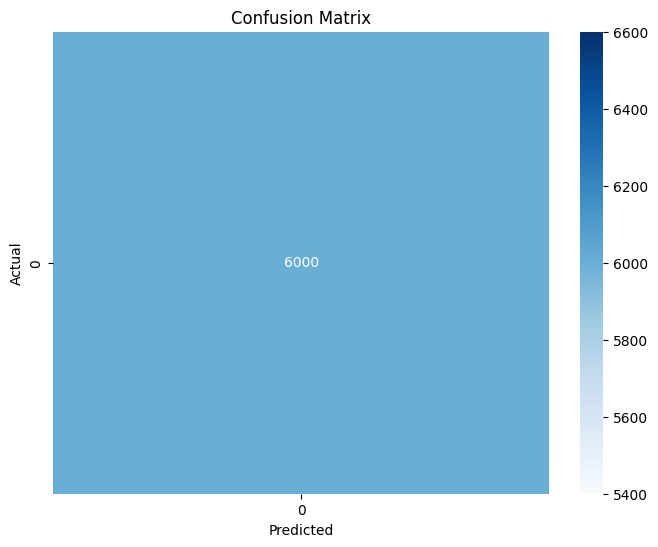

In [21]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))

sns.heatmap(

cm,

annot=True,

fmt="d",

cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [22]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance = model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
24119,cat__reason_code_STALE_LOW_CTR,0.0
0,num__search_volume,0.0
1,num__competition,0.0
2,num__cpc,0.0
3,num__word_count,0.0
4,num__char_count,0.0
5,num__impressions_90d,0.0
6,num__clicks_90d,0.0
24103,cat__position_tier_striking,0.0
24102,cat__position_tier_page_3_5,0.0


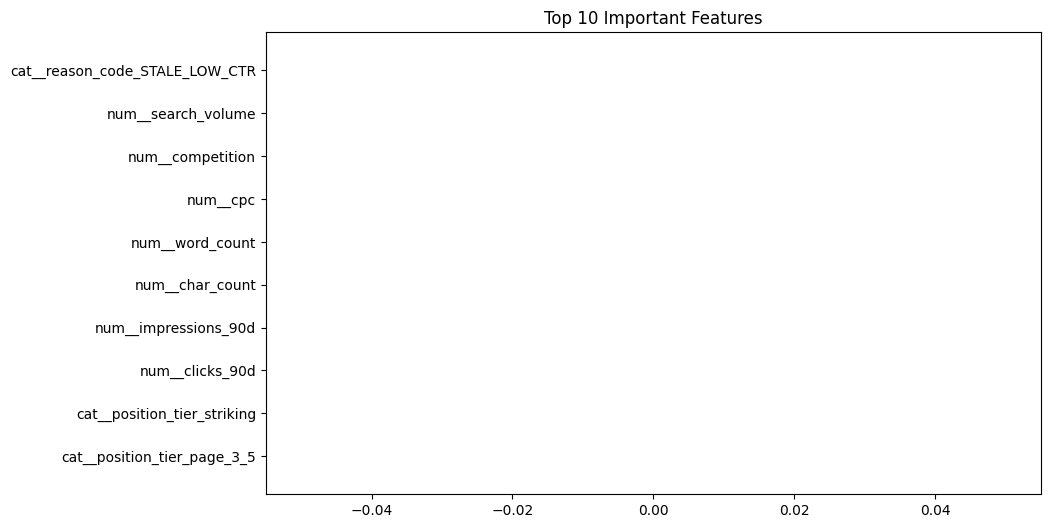

In [23]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

### Error Analysis

Although Random Forest performed well, some records were still misclassified.

Possible reasons include overlapping feature values, noisy observations, and class imbalance.

Feature importance indicates that only a subset of variables strongly influence the prediction.

Future improvements could include hyperparameter tuning, cross-validation, and Gradient Boosting models.

In [24]:
errors = X_test.copy()

errors["Actual"] = y_test.values

errors["Predicted"] = predictions

errors[errors["Actual"] != errors["Predicted"]].head(10)

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,impression_tier,position_tier,trend_direction,trend_pct,ctr_bucket,update_bucket,score,reason_code,Actual,Predicted


# Conclusion

A Random Forest Classifier was trained on the FlyRank baseline dataset to predict the recommended content action.

The model successfully learned from both numerical and categorical features using preprocessing pipelines.

Performance was evaluated using accuracy, classification report, confusion matrix, and feature importance.

Compared with the Week-4 rule-based baseline, this approach provides a data-driven prediction model and interpretable feature rankings.

## Self-check

Before you submit, confirm each line honestly:

-  Every section above is filled — markdown thinking AND the code that backs it
- The notebook runs top to bottom with no errors (Runtime → Run all)
- No client names, URLs, or private queries anywhere
- My claims use careful words: observed, measured, directional, decision-support
- Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.